In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
df = pd.read_csv("D:\DATA SCIENCE\Projects\Capstone_Project\Datasets\cleaned_amazon_audio.csv")

In [2]:
df.columns

Index(['asin', 'product_title', 'brand', 'price', 'discount_percent', 'rating',
       'review_count', 'category', 'product_link', 'search_term',
       'value_score', 'device_type', 'is_wired', 'has_mic'],
      dtype='object')

### Log the extreme value to prevent ouliers

In [3]:
import numpy as np

df['price'] = np.log1p(df['price'])
df['review_count'] = np.log1p(df['review_count'])

### Assigning the 'x' variables

In [4]:
x = df[['price', 'rating', 'review_count' ]]

### Standardisation

In [5]:
from sklearn.preprocessing import StandardScaler
sclaer = StandardScaler()
x_scaled = sclaer.fit_transform(x)

### Calculating the wcss

In [6]:
from sklearn.cluster import KMeans
wcss = []
for k in range(2,10):
    m = KMeans( n_clusters = k, random_state = 42 )
    m.fit(x_scaled)
    wcss.append(m.inertia_)
        

### Elbow curve

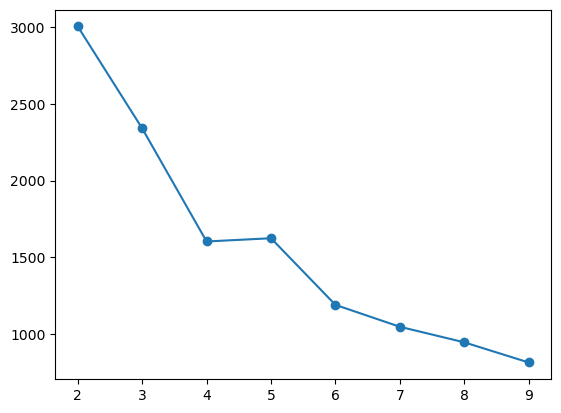

In [7]:
import matplotlib.pyplot as plt
plt.plot(range(2,10), wcss, marker = 'o')
plt.show()

### Calculating silhouette score

In [8]:
from sklearn.metrics import silhouette_score

for k in range(2,10):
    m = KMeans(n_clusters=k,random_state=42)
    labels = m.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    print(f"k = {k} Silhouette Score = {score:.4f}")

k = 2 Silhouette Score = 0.2990
k = 3 Silhouette Score = 0.3083
k = 4 Silhouette Score = 0.3587
k = 5 Silhouette Score = 0.2830
k = 6 Silhouette Score = 0.3241
k = 7 Silhouette Score = 0.3319
k = 8 Silhouette Score = 0.3136
k = 9 Silhouette Score = 0.3309


### Optimal K = 4

In [9]:
m1 = KMeans(n_clusters=4, random_state=42)
clusters = m1.fit_predict(x_scaled)

In [10]:
df['cluster'] = clusters

In [11]:
df.groupby('cluster')[['price','rating','review_count']].mean()

,price,rating,review_count
cluster,,,
0,6.537041,4.217403,1.565898
1,6.908696,3.859664,7.303750
2,9.452326,4.229581,6.374817
3,6.565967,2.366055,2.231570


### Segmenting the cluster

In [12]:
segment_map = {
    0: "High Rated",
    1: "Popular",
    2: "Premium",
    3: "Low Rated"
}

df['segment'] = df['cluster'].map(segment_map)

In [13]:
df['segment'].value_counts()

segment
Popular       595
Premium       382
High Rated    362
Low Rated     109
Name: count, dtype: int64

In [ ]:
Cluster 1 → Popular
Lots of reviews
Average rating
Frequently bought products

In [ ]:
Cluster 2 → Premium
Expensive
Good rating
High-end products

In [ ]:
luster 3 → Low Rated
Poor ratings
Not recommended

In [ ]:
df.to_csv("clusterd_amazon_audio.csv", index=False)